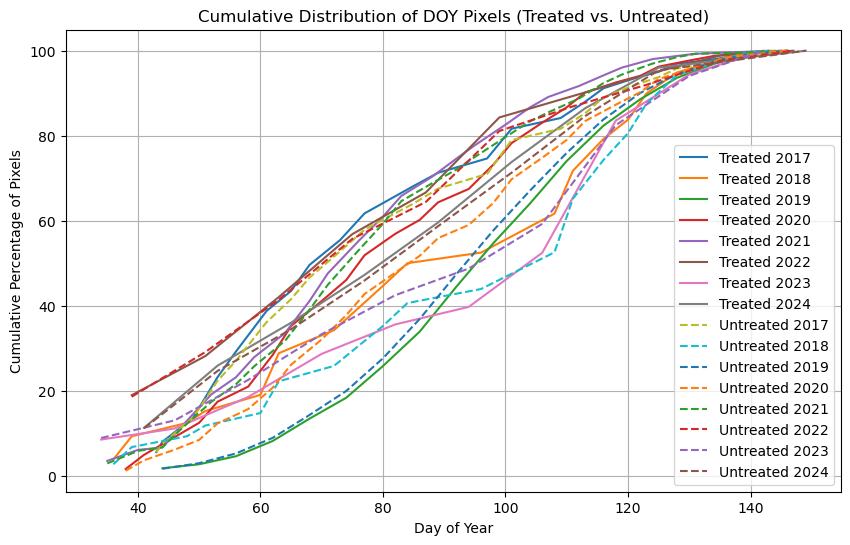

In [5]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd

# Define folders
folder_treated = "treated_corrected"
folder_untreated = "untreated_corrected"

# Function to extract year from filename (expects 'treated_YYYY.tif' or 'untreated_YYYY.tif')
def extract_year(filename):
    parts = filename.split("_")  # Split by underscore
    year_part = parts[-1].replace(".tif", "")  # Extract last part and remove extension
    if year_part.isdigit() and len(year_part) == 4:  # Ensure it's a valid year
        return int(year_part)
    else:
        raise ValueError(f"Could not extract year from filename: {filename}")

# Function to compute cumulative DOY distribution
def compute_cumulative_distribution(folder):
    data = {}

    for file in sorted(os.listdir(folder)):  # Ensure chronological order
        if file.endswith(".tif"):
            try:
                year = extract_year(file)  # Extract year from filename
                with rasterio.open(os.path.join(folder, file)) as src:
                    raster_data = src.read(1)  # Read raster band
                    valid_pixels = raster_data[raster_data > 0]  # Ignore no-data/zero values
                    
                    unique, counts = np.unique(valid_pixels, return_counts=True)
                    pixel_counts = dict(zip(unique, counts))
                    
                    # Convert to cumulative percentage
                    total_pixels = sum(pixel_counts.values())
                    df = pd.DataFrame({"DOY": list(pixel_counts.keys()), "Count": list(pixel_counts.values())})
                    df = df.sort_values("DOY")  # Sort by DOY
                    df["Cumulative %"] = (df["Count"].cumsum() / total_pixels) * 100
                    
                    data[year] = df
            
            except ValueError as e:
                print(f"Skipping file {file}: {e}")

    return data

# Compute distributions for treated and untreated data
data_treated = compute_cumulative_distribution(folder_treated)
data_untreated = compute_cumulative_distribution(folder_untreated)

# Plot results
plt.figure(figsize=(10, 6))
for year, df in data_treated.items():
    plt.plot(df["DOY"], df["Cumulative %"], label=f"Treated {year}")

for year, df in data_untreated.items():
    plt.plot(df["DOY"], df["Cumulative %"], linestyle="dashed", label=f"Untreated {year}")

plt.xlabel("Day of Year")
plt.ylabel("Cumulative Percentage of Pixels")
plt.title("Cumulative Distribution of DOY Pixels (Treated vs. Untreated)")
plt.legend()
plt.grid()
plt.show()


Year 2017:
  Treated: 97.58 / (1 + exp(-0.0631 * (x - 70.95)))
  Untreated: 98.55 / (1 + exp(-0.0570 * (x - 73.84)))

Year 2018:
  Treated: 120.51 / (1 + exp(-0.0387 * (x - 98.74)))
  Untreated: 132.44 / (1 + exp(-0.0392 * (x - 109.92)))

Year 2019:
  Treated: 103.74 / (1 + exp(-0.0692 * (x - 96.48)))
  Untreated: 103.18 / (1 + exp(-0.0700 * (x - 94.67)))

Year 2020:
  Treated: 101.41 / (1 + exp(-0.0596 * (x - 79.00)))
  Untreated: 103.49 / (1 + exp(-0.0554 * (x - 86.75)))

Year 2021:
  Treated: 100.06 / (1 + exp(-0.0674 * (x - 74.21)))
  Untreated: 99.65 / (1 + exp(-0.0653 * (x - 75.65)))

Year 2022:
  Treated: 103.32 / (1 + exp(-0.0471 * (x - 71.32)))
  Untreated: 103.57 / (1 + exp(-0.0437 * (x - 72.67)))

Year 2023:
  Treated: 148.49 / (1 + exp(-0.0344 * (x - 117.23)))
  Untreated: 135.95 / (1 + exp(-0.0331 * (x - 108.56)))

Year 2024:
  Treated: 106.76 / (1 + exp(-0.0448 * (x - 81.85)))
  Untreated: 107.35 / (1 + exp(-0.0439 * (x - 83.59)))



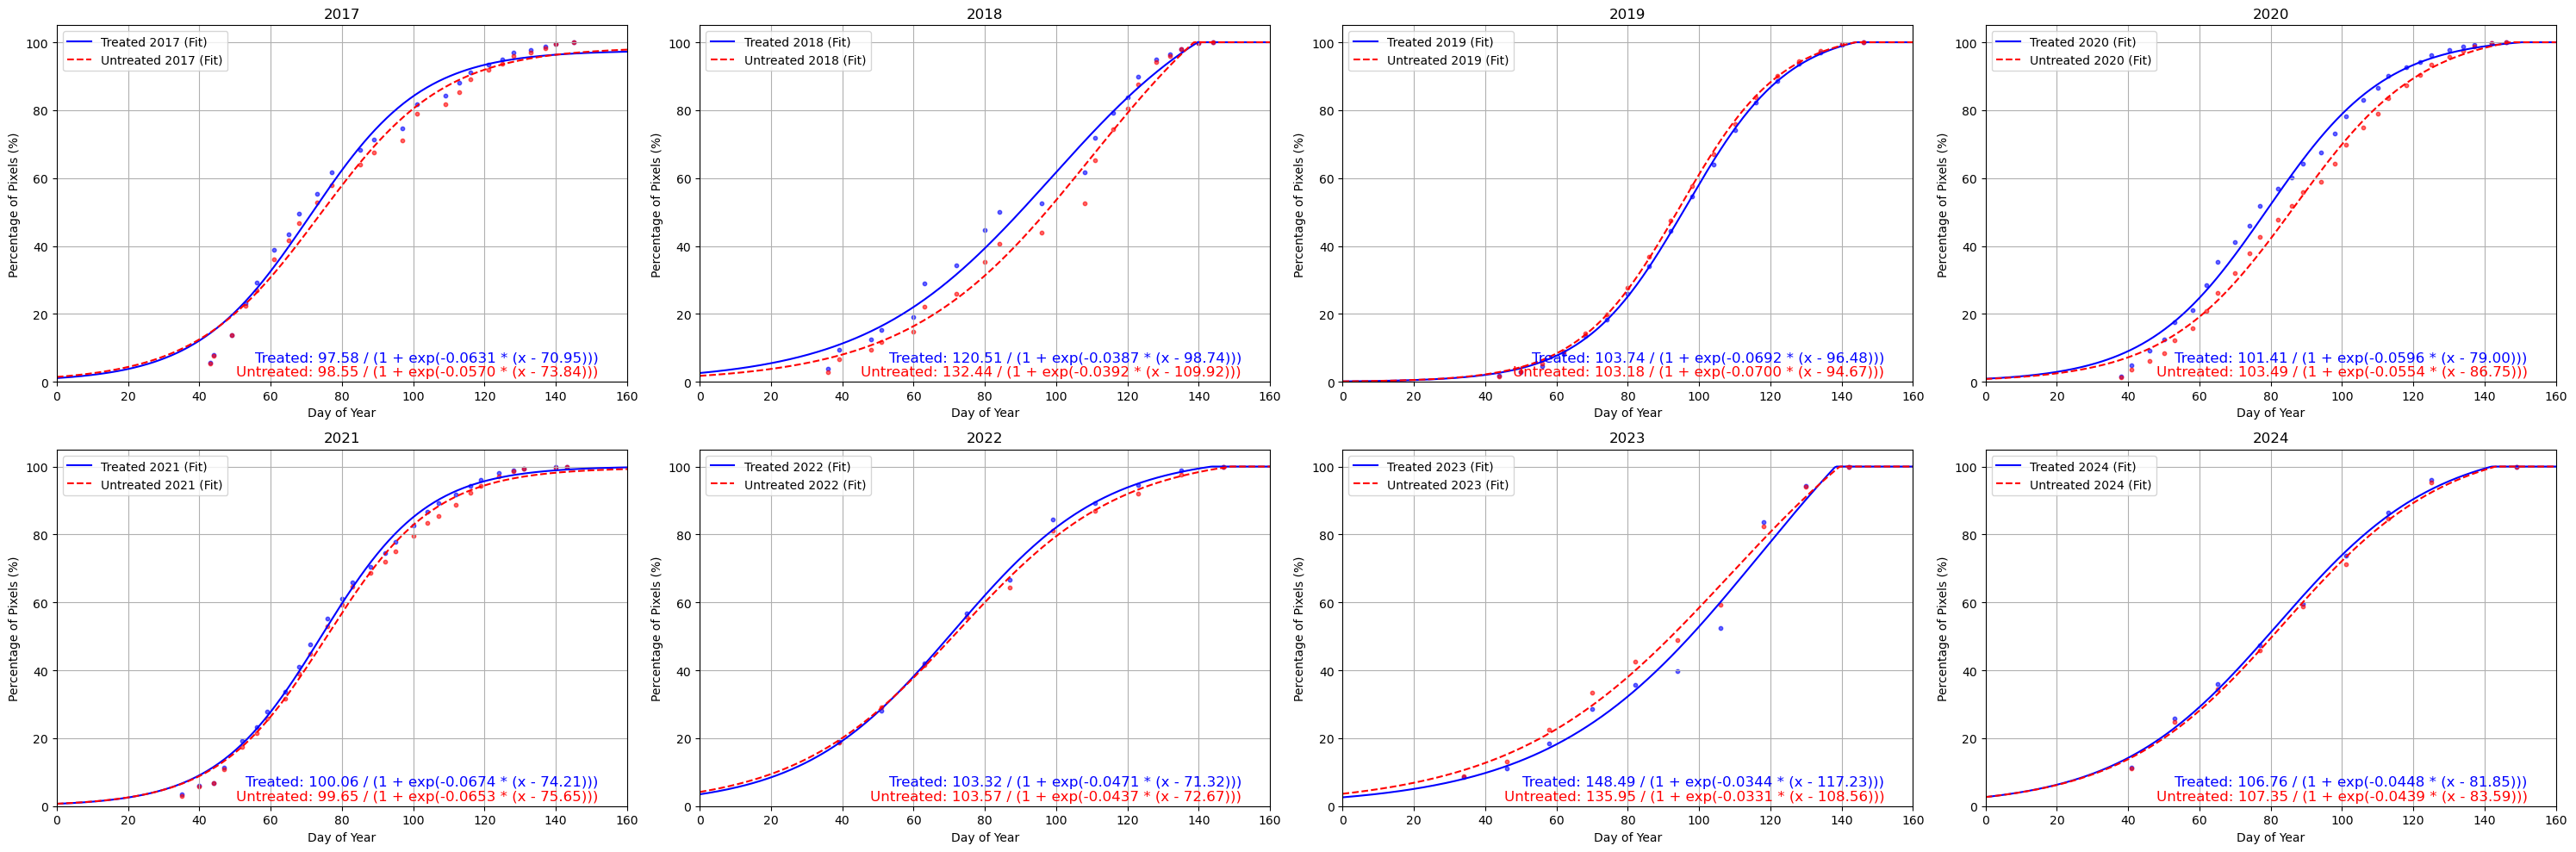

In [5]:
## CUMULATIVE CURVE PLOT ##
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Define folders
folder_treated = "treated_corrected"
folder_untreated = "untreated_corrected"

# Function to extract year from filename
def extract_year(filename):
    parts = filename.split("_")  # Split by underscore
    year_part = parts[-1].replace(".tif", "")  # Extract last part and remove extension
    if year_part.isdigit() and len(year_part) == 4:
        return int(year_part)
    else:
        raise ValueError(f"Could not extract year from filename: {filename}")

# Logistic function (sigmoid) for fitting
def logistic_function(x, L, x0, k):
    return L / (1 + np.exp(-k * (x - x0)))

# Function to compute cumulative DOY distribution
def compute_cumulative_distribution(folder):
    data = {}

    for file in sorted(os.listdir(folder)):  # Ensure chronological order
        if file.endswith(".tif"):
            try:
                year = extract_year(file)  # Extract year from filename
                with rasterio.open(os.path.join(folder, file)) as src:
                    raster_data = src.read(1)  # Read raster band
                    valid_pixels = raster_data[raster_data > 0]  # Ignore no-data/zero values
                    
                    unique, counts = np.unique(valid_pixels, return_counts=True)
                    pixel_counts = dict(zip(unique, counts))
                    
                    # Convert to cumulative percentage
                    total_pixels = sum(pixel_counts.values())
                    df = pd.DataFrame({"DOY": list(pixel_counts.keys()), "Count": list(pixel_counts.values())})
                    df = df.sort_values("DOY")  # Sort by DOY
                    df["Cumulative %"] = (df["Count"].cumsum() / total_pixels) * 100
                    
                    data[year] = df
            
            except ValueError as e:
                print(f"Skipping file {file}: {e}")

    return data

# Compute distributions
data_treated = compute_cumulative_distribution(folder_treated)
data_untreated = compute_cumulative_distribution(folder_untreated)

# Create separate plots for each year
years = sorted(set(data_treated.keys()).intersection(data_untreated.keys()))  # Only plot years in both datasets
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(30, 10))  # 4x2 grid for 8 years

for ax, year in zip(axes.flat, years):
    df_treated = data_treated[year]
    df_untreated = data_untreated[year]

    # Fit logistic function to treated data
    x_treated = df_treated["DOY"].values
    y_treated = df_treated["Cumulative %"].values
    popt_treated, _ = curve_fit(logistic_function, x_treated, y_treated, p0=[100, 180, 0.1])

    # Fit logistic function to untreated data
    x_untreated = df_untreated["DOY"].values
    y_untreated = df_untreated["Cumulative %"].values
    popt_untreated, _ = curve_fit(logistic_function, x_untreated, y_untreated, p0=[100, 180, 0.1])

    # Generate smooth curve using fitted parameters, extending to DOY 160
    x_fit = np.linspace(0, 160, 300)  # Extended range from 0 to 160
    y_fit_treated = np.minimum(logistic_function(x_fit, *popt_treated), 100)  # Clip at 100%
    y_fit_untreated = np.minimum(logistic_function(x_fit, *popt_untreated), 100)  # Clip at 100%

    # Extract fitted parameters
    L_treated, x0_treated, k_treated = popt_treated
    L_untreated, x0_untreated, k_untreated = popt_untreated

    # Display equations
    equation_treated = f"Treated: {L_treated:.2f} / (1 + exp(-{k_treated:.4f} * (x - {x0_treated:.2f})))"
    equation_untreated = f"Untreated: {L_untreated:.2f} / (1 + exp(-{k_untreated:.4f} * (x - {x0_untreated:.2f})))"

    # Print equations to console
    print(f"Year {year}:")
    print("  " + equation_treated)
    print("  " + equation_untreated)
    print()

    # Plot raw data points
    ax.scatter(x_treated, y_treated, color="blue", s=10, alpha=0.6)
    ax.scatter(x_untreated, y_untreated, color="red", s=10, alpha=0.6)

    # Plot fitted curves, ensuring they extend to 160 and remain at 100%
    ax.plot(x_fit, y_fit_treated, color="blue", label=f"Treated {year} (Fit)")
    ax.plot(x_fit, y_fit_untreated, linestyle="dashed", color="red", label=f"Untreated {year} (Fit)")

    # Display equations in the lower right
    ax.text(0.95, 0.05, equation_treated, transform=ax.transAxes, fontsize=12, color="blue", ha="right", va="bottom")
    ax.text(0.95, 0.01, equation_untreated, transform=ax.transAxes, fontsize=12, color="red", ha="right", va="bottom")

    ax.set_xlim(0, 160)  # Force x-axis to go from 0 to 160
    ax.set_ylim(0, 105)  # Keep space above 100% for clarity
    ax.set_title(f"{year}")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Percentage of Pixels (%)")
    ax.legend()
    ax.grid()

plt.tight_layout()  # Adjust layout for readability
plt.savefig("cumulative_SAR.png", dpi=300)  # Save as PNG at 300 dpi
plt.show()


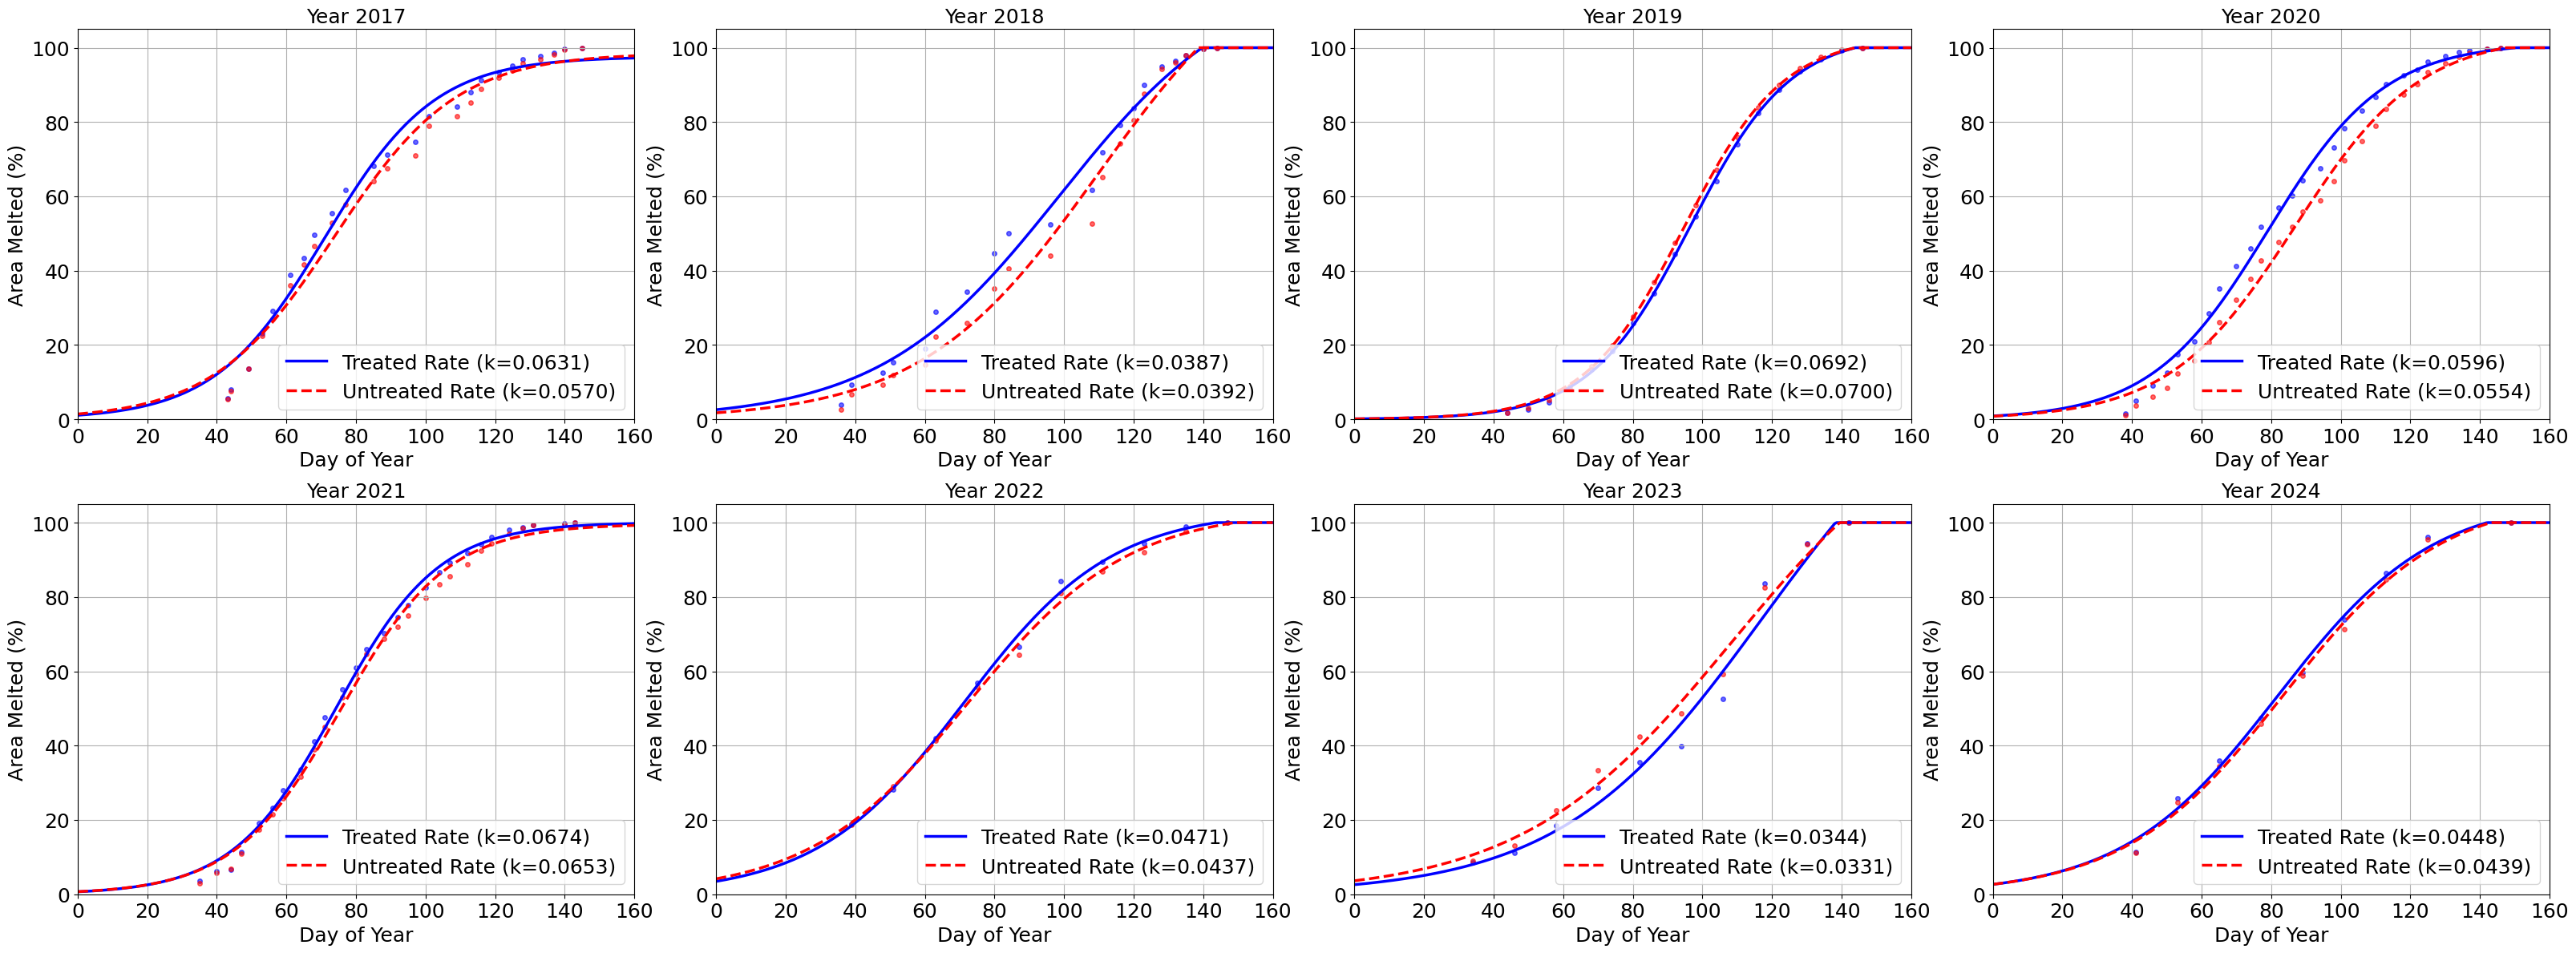

In [10]:
## Anna's Class improved plot ##
# Create separate plots for each year
years = sorted(set(data_treated.keys()).intersection(data_untreated.keys()))
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(32, 12))  # Larger figure

for ax, year in zip(axes.flat, years):
    df_treated = data_treated[year]
    df_untreated = data_untreated[year]

    # Fit logistic functions
    x_treated = df_treated["DOY"].values
    y_treated = df_treated["Cumulative %"].values
    popt_treated, _ = curve_fit(logistic_function, x_treated, y_treated, p0=[100, 180, 0.1])

    x_untreated = df_untreated["DOY"].values
    y_untreated = df_untreated["Cumulative %"].values
    popt_untreated, _ = curve_fit(logistic_function, x_untreated, y_untreated, p0=[100, 180, 0.1])

    # Generate fitted curves
    x_fit = np.linspace(0, 160, 300)
    y_fit_treated = np.minimum(logistic_function(x_fit, *popt_treated), 100)
    y_fit_untreated = np.minimum(logistic_function(x_fit, *popt_untreated), 100)

    # Extract growth rates
    k_treated = popt_treated[2]
    k_untreated = popt_untreated[2]

    # Plot
    ax.scatter(x_treated, y_treated, color="blue", s=16, alpha=0.6)
    ax.scatter(x_untreated, y_untreated, color="red", s=16, alpha=0.6)

    ax.plot(x_fit, y_fit_treated, color="blue", linewidth=2.5, label=f"Treated Rate (k={k_treated:.4f})")
    ax.plot(x_fit, y_fit_untreated, color="red", linestyle="--", linewidth=2.5, label=f"Untreated Rate (k={k_untreated:.4f})")

    ax.set_xlim(0, 160)
    ax.set_ylim(0, 105)
    ax.set_title(f"Year {year}", fontsize=18)
    ax.set_xlabel("Day of Year", fontsize=18)
    ax.set_ylabel("Area Melted (%)", fontsize=18)
    ax.tick_params(axis='both', labelsize=18)
    ax.grid(True)
    ax.legend(fontsize=18, loc='lower right')

plt.tight_layout()
plt.savefig("cumulative_SAR_improved.png", dpi=300)
plt.show()


Year 2017: KS Statistic = 0.0412, p-value = 0.0000
Year 2018: KS Statistic = 0.0943, p-value = 0.0000
Year 2019: KS Statistic = 0.0303, p-value = 0.0000
Year 2020: KS Statistic = 0.0913, p-value = 0.0000
Year 2021: KS Statistic = 0.0362, p-value = 0.0000
Year 2022: KS Statistic = 0.0319, p-value = 0.0000
Year 2023: KS Statistic = 0.0902, p-value = 0.0000
Year 2024: KS Statistic = 0.0251, p-value = 0.0000


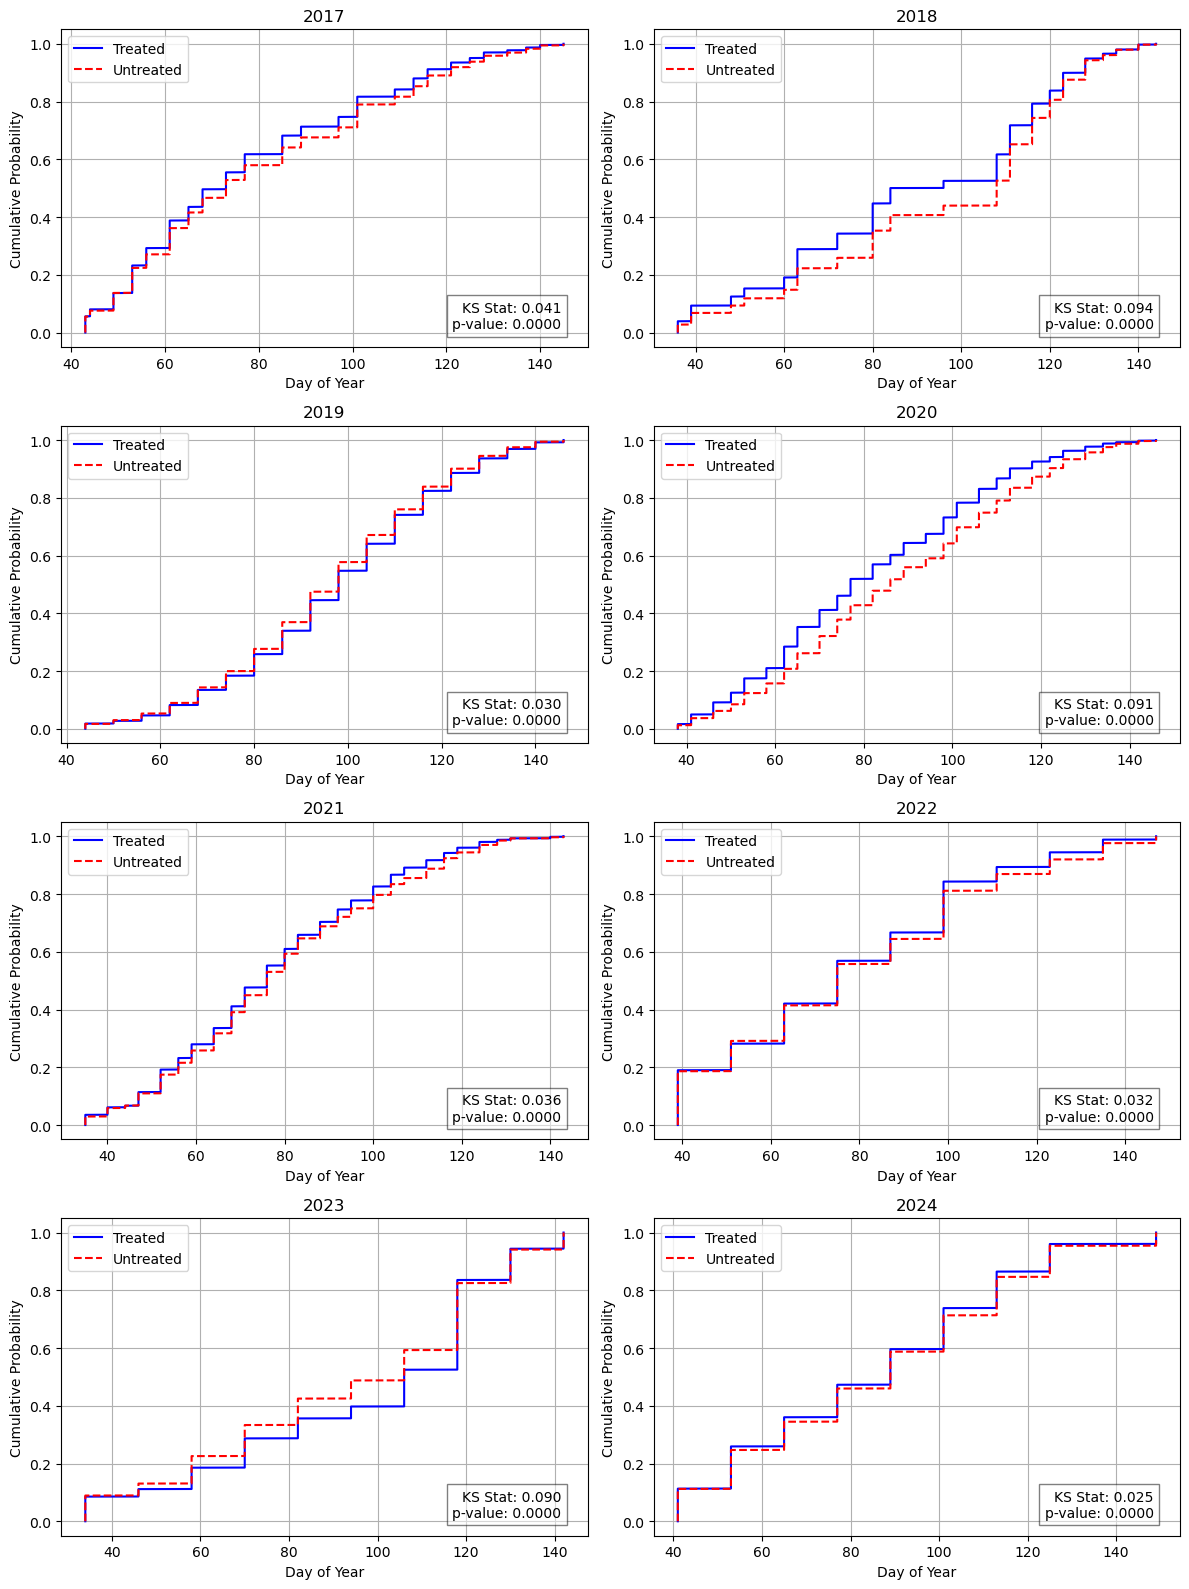

In [8]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import ks_2samp

# Define folders
folder_treated = "treated_corrected"
folder_untreated = "untreated_corrected"

# Function to extract year from filename
def extract_year(filename):
    parts = filename.split("_")
    year_part = parts[-1].replace(".tif", "")
    if year_part.isdigit() and len(year_part) == 4:
        return int(year_part)
    else:
        raise ValueError(f"Could not extract year from filename: {filename}")

# Function to compute empirical cumulative distribution function (ECDF)
def ecdf(data):
    sorted_data = np.sort(data)
    y_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, y_vals

# Function to load and process raster data
def load_raster_data(folder):
    data_dict = {}
    
    for file in sorted(os.listdir(folder)):  # Ensure chronological order
        if file.endswith(".tif"):
            try:
                year = extract_year(file)
                with rasterio.open(os.path.join(folder, file)) as src:
                    raster_data = src.read(1)  # Read raster band
                    valid_pixels = raster_data[raster_data > 0]  # Ignore no-data/zero values
                    data_dict[year] = valid_pixels
            except ValueError as e:
                print(f"Skipping file {file}: {e}")

    return data_dict

# Load treated and untreated data
data_treated = load_raster_data(folder_treated)
data_untreated = load_raster_data(folder_untreated)

# Get the common years in both datasets
years = sorted(set(data_treated.keys()).intersection(data_untreated.keys()))

# Create KS test plots for each year
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 16))  # 4x2 grid for 8 years

for ax, year in zip(axes.flat, years):
    treated_values = data_treated[year]
    untreated_values = data_untreated[year]

    # Compute ECDFs
    x_treated, y_treated = ecdf(treated_values)
    x_untreated, y_untreated = ecdf(untreated_values)

    # Perform KS test
    ks_statistic, p_value = ks_2samp(treated_values, untreated_values)

    # Interpolate ECDFs onto a common set of x-values
    common_x = np.union1d(x_treated, x_untreated)  # Merge x-values for consistency
    y_interp_treated = np.interp(common_x, x_treated, y_treated, left=0, right=1)
    y_interp_untreated = np.interp(common_x, x_untreated, y_untreated, left=0, right=1)

    # Find max vertical difference (KS statistic location)
    ks_index = np.argmax(np.abs(y_interp_treated - y_interp_untreated))
    ks_x = common_x[ks_index]  # x-value where max difference occurs
    ks_y1 = y_interp_treated[ks_index]
    ks_y2 = y_interp_untreated[ks_index]

    # Plot ECDFs
    ax.plot(x_treated, y_treated, label="Treated", color="blue")
    ax.plot(x_untreated, y_untreated, label="Untreated", color="red", linestyle="dashed")

    # Mark KS statistic (max difference)
    #ax.vlines(x=ks_x, ymin=ks_y1, ymax=ks_y2, color="black", linewidth=2, label=f"KS Stat = {ks_statistic:.3f}")

    # Add KS statistic text in the lower right
    ax.text(0.95, 0.05, f"KS Stat: {ks_statistic:.3f}\np-value: {p_value:.4f}", 
            transform=ax.transAxes, fontsize=10, color="black", 
            verticalalignment="bottom", horizontalalignment="right",
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))

    # Add title and labels
    ax.set_title(f"{year}")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Cumulative Probability")
    ax.legend()
    ax.grid()

    # Print KS test result
    print(f"Year {year}: KS Statistic = {ks_statistic:.4f}, p-value = {p_value:.4f}")

plt.tight_layout()  # Adjust layout for readability
plt.savefig("KS_test_plots", bbox_inches="tight", dpi=300)
plt.show()
